In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb

!pip install optuna
import optuna
from optuna.samplers import TPESampler


import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.0 MB/s eta 0:00:00
Libraries imported successfully!


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [ ]:
df = pd.read_csv("data_B.csv")
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [ ]:
df.shape[0] # jumlah baris

25000

In [ ]:
df.shape[1] # jumlah kolom

29

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Bisa dilihat secara sekilas bahwa ada anomali yang terjadi di dataset ini yaitu kolom - kolom yang harusnya berbentuk angka malah dimasukkan ke dalam jenis object. Contoh kolom-kolom tersebut adalah:

Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt Amount_invested_monthly, Monthly_Balance. Kolom - kolom ini akan saya handle di categorical checking untuk melihat penyebab mereka menjadi object instead of int.

Dari atas juga dapat dilihat ada beberapa kolom yang memiliki missing value. Saya akan mengecek distribusinya terlebih dahulu lalu baru bisa memutuskan langkah apa suntuk menghandle missing value ini.



In [ ]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,13257
Poor,7197
Good,4546


  Target di dataset ini adalah kolom 'Credit_Score' yang menunjukkan Standart, Poor, dan Good
  

# EDA

## Drop kolom yang tidak diperlukan

Disini saya akan melakukan drop kolom untuk kolom-kolom yang tidak diperlukan karena bernilai unique dan tidak berpengaruh pada model nantinya.

In [ ]:
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Unnamed: 0', 'Month'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  object 
 1   Occupation                25000 non-null  object 
 2   Annual_Income             25000 non-null  object 
 3   Monthly_Inhand_Salary     21244 non-null  float64
 4   Num_Bank_Accounts         25000 non-null  int64  
 5   Num_Credit_Card           25000 non-null  int64  
 6   Interest_Rate             25000 non-null  int64  
 7   Num_of_Loan               25000 non-null  object 
 8   Type_of_Loan              22152 non-null  object 
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    23267 non-null  object 
 11  Changed_Credit_Limit      25000 non-null  object 
 12  Num_Credit_Inquiries      24510 non-null  float64
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

## Incosistency Handling

Jadi setelah dicek, ada beberapa kolom yang tipe datanya tidak sesuai dengan seharusnya. Contohnya Age yang jadi object padahal harusnya int. Hal yang serupa juga terjadi di beberapa fitur jadi saya melakukan pengecekan dan handling untuk mengubah type data yang salah ke type data sebenarnya.

In [ ]:
suspect_cols = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in suspect_cols:
    temp = pd.to_numeric(df[col], errors='coerce')
    invalid = df[temp.isna() & df[col].notna()][col].unique()

    print(f"\n{'='*50}")
    print(f"Invalid values in {col}:")
    print(f"{'='*50}")
    print(invalid[:20])
    print(f"Total invalid values: {len(invalid)}")


Invalid values in Age:
['39_' '29_' '44_' '46_' '48_' '36_' '17_' '43_' '41_' '32_' '19_' '22_'
 '52_' '47_' '50_' '53_' '33_' '38_' '16_' '27_']
Total invalid values: 62

Invalid values in Annual_Income:
['120539.8_' '22433.46_' '46352.82_' '72902.70000000001_' '121813.72_'
 '160573.56_' '14179.49_' '42103.18_' '19604.35_' '14006.745_' '22431.61_'
 '167067.08_' '44986.07_' '43592.45_' '13672.2_' '55473.18000000001_'
 '45033.54_' '8723.565_' '8002.575_' '16974.83_']
Total invalid values: 1651

Invalid values in Num_of_Loan:
['6_' '9_' '2_' '4_' '0_' '7_' '5_' '3_' '1_' '8_' '1171_' '785_' '1027_'
 '1320_' '359_']
Total invalid values: 15

Invalid values in Num_of_Delayed_Payment:
['14_' '23_' '17_' '9_' '12_' '8_' '15_' '0_' '11_' '10_' '13_' '20_'
 '18_' '1_' '2_' '22_' '19_' '7_' '25_' '16_']
Total invalid values: 33

Invalid values in Changed_Credit_Limit:
['_']
Total invalid values: 1

Invalid values in Outstanding_Debt:
['2783.29_' '809.86_' '725.53_' '4921.57_' '708.2_' '340.22_

Setelah melihat semua value yang membuat tipe data ini rusak, saya memutuskan untuk menghandle dengan cara menghapus karakter aneh di tiap kolom lalu mengubahnya ke jenis data numeric.

In [ ]:
cols_clean = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Outstanding_Debt'
]

for col in cols_clean:
    df[col] = df[col].astype(str).str.replace('_', '', regex=False)

# special invalid placeholders
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('_', np.nan)

df['Amount_invested_monthly'] = (
    df['Amount_invested_monthly']
    .astype(str)
    .str.replace('_', '', regex=False)
)

df['Monthly_Balance'] = df['Monthly_Balance'].replace(
    '__-333333333333333333333333333__',
    np.nan
)

# convert to numeric
numeric_cols = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Berikut tampilan data info setelah dilakukan data inkosistensi handling

In [ ]:
df.dtypes

,0
Age,int64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64
Interest_Rate,int64
Num_of_Loan,int64
Type_of_Loan,object
Delay_from_due_date,int64


In [ ]:
df[numeric_cols].dtypes

,0
Age,int64
Annual_Income,float64
Num_of_Loan,int64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64
Outstanding_Debt,float64
Amount_invested_monthly,float64
Monthly_Balance,float64


In [ ]:
df.select_dtypes(include='object').dtypes

,0
Occupation,object
Type_of_Loan,object
Credit_Mix,object
Credit_History_Age,object
Payment_of_Min_Amount,object
Payment_Behaviour,object
Credit_Score,object


## Missing Value

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  int64  
 1   Occupation                25000 non-null  object 
 2   Annual_Income             25000 non-null  float64
 3   Monthly_Inhand_Salary     21244 non-null  float64
 4   Num_Bank_Accounts         25000 non-null  int64  
 5   Num_Credit_Card           25000 non-null  int64  
 6   Interest_Rate             25000 non-null  int64  
 7   Num_of_Loan               25000 non-null  int64  
 8   Type_of_Loan              22152 non-null  object 
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    23267 non-null  float64
 11  Changed_Credit_Limit      24468 non-null  float64
 12  Num_Credit_Inquiries      24510 non-null  float64
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum()/len(df))*100
})

missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
Monthly_Inhand_Salary,3756,15.024
Type_of_Loan,2848,11.392
Credit_History_Age,2292,9.168
Num_of_Delayed_Payment,1733,6.932
Amount_invested_monthly,1060,4.240
Changed_Credit_Limit,532,2.128
Num_Credit_Inquiries,490,1.960
Monthly_Balance,303,1.212


### Categorical Checking

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).head(15))


===== Occupation =====
Occupation
_______          1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Name: count, dtype: int64

===== Type_of_Loan =====
Type_of_Loan
NaN                                      2848
Not Specified                             367
Student Loan                              317
Credit-Builder Loan                       315
Personal Loan                             304
Debt Consolidation Loan                   301
Payday Loan                               285
Auto Loan                                 282
Home Equity Loan                          281
Mortgage Loan                             273
Not Specified, and Payday Loan             80
Mortgage Loan, and Home Equity Loan        76
Student Loan, and 

#### Occupation

di occupation terdapat 1792 data kosong tetap jika langsung melakukan drop, maka saya akan kehilangan banyak data penting sehingg saya memutuskan untuk menggantinya dengan 'unknown' agar dapat lebih mudah diinterpretasikan.

In [ ]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)

In [ ]:
df['Occupation'].unique()

array(['Architect', 'Lawyer', 'Writer', 'Teacher', 'Media_Manager',
       'Entrepreneur', 'Scientist', 'Doctor', 'Musician', 'Journalist',
       'Mechanic', 'Accountant', nan, 'Engineer', 'Manager', 'Developer'],
      dtype=object)

#### Credit_Mix

di kolom credit_mix ada sebanyak 5172 data kosong sehingga sementara saya akan mengubahnya menjadi missing value.

In [ ]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

In [ ]:
df['Credit_Mix'].unique()

array(['Bad', 'Good', nan, 'Standard'], dtype=object)

#### Payment_of_Min_Amount  


di kolom payment of minimal amount ada NM (Not Mentioned) jadi saya akan mengubahnya menjadi np.nan untuk sementara

In [ ]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

#### Payment_Behaviour

di payment_behaviour terdapat karakter aneh yang mengganggu jadi saya akan mengubahnya sementara menjadi missing value

In [ ]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

#### Credit_History_Age (masuknya feature engineering)

Credit History Age akan saya ubah satuannya dari tahun + bulan menjadi bulan secara keseluruhan agar lebih gampang diinterpretasikan.

In [ ]:
def convert_credit_history(age):
    if pd.isna(age):
        return np.nan

    parts = age.split()
    years = int(parts[0])
    months = int(parts[3])

    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_history)

Type_of_Loan akan saya handle nanti di feature engineering.

In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing[missing['Missing Count'] > 0].sort_values(
    by='Missing Count',
    ascending=False
)

,Missing Count,Missing Percentage
Credit_Mix,5172,20.688
Monthly_Inhand_Salary,3756,15.024
Payment_of_Min_Amount,3082,12.328
Type_of_Loan,2848,11.392
Credit_History_Age,2292,9.168
Payment_Behaviour,1903,7.612
Occupation,1792,7.168
Num_of_Delayed_Payment,1733,6.932
Amount_invested_monthly,1060,4.240
Changed_Credit_Limit,532,2.128


In [ ]:
df['Occupation'].fillna('Unknown', inplace=True)

missing value dari occupation sebesar 7% diubah menjadi unknown sebagai penanda bahwa pekerja responden unknown tanpa menghilangkan kolom-kolom lain yang lebih penting (kalau didrop)

In [ ]:
df['Type_of_Loan'].fillna('Unknown', inplace=True)

Missing value yang ada di loan type bisa jadi menunjukkan informasi tidak tersedia atau tidak ditentukan, bukan tidak adanya pinjaman. Oleh karena itu, kategori “Tidak Diketahui” digunakan sebagai cara imputasi untuk menghindari asumsi.

In [ ]:
df['Credit_Mix'].fillna(df['Credit_Mix'].mode()[0], inplace=True)

Since Credit_Mix represents a predefined categorical financial classification, mode imputation was selected to preserve consistency within the existing category structure.

In [ ]:
df['Payment_of_Min_Amount'].fillna(
    df['Payment_of_Min_Amount'].mode()[0],
    inplace=True
)

Payment_of_Min_Amount akan diimputasi menggunakan modus karena bersifat binary sehingga modus adalah best practice dibandingkan dengan menambah entri baru 'unknown' atau drop yang menyebabkan kehilangan banyak data penting

In [ ]:
df['Payment_Behaviour'].fillna(
    df['Payment_Behaviour'].mode()[0],
    inplace=True
)

Karena hanya 7% dan disebabkan oleh karakter tidak jelas. Saya memutuskan untuk mengimputasi dengan modus.

In [ ]:
df.select_dtypes(include='object').isnull().sum()

,0
Occupation,0
Type_of_Loan,0
Credit_Mix,0
Payment_of_Min_Amount,0
Payment_Behaviour,0
Credit_Score,0


### Numerical Checking

In [ ]:
numeric_missing = df.select_dtypes(include=['int64', 'float64']).isnull().sum()

numeric_missing = numeric_missing[numeric_missing > 0]

numeric_missing_df = pd.DataFrame({
    'Missing Count': numeric_missing,
    'Missing Percentage (%)': (numeric_missing / len(df)) * 100
}).sort_values(by='Missing Count', ascending=False)

numeric_missing_df

,Missing Count,Missing Percentage (%)
Monthly_Inhand_Salary,3756,15.024
Credit_History_Age,2292,9.168
Num_of_Delayed_Payment,1733,6.932
Amount_invested_monthly,1060,4.240
Changed_Credit_Limit,532,2.128
Num_Credit_Inquiries,490,1.960
Monthly_Balance,303,1.212


* Skewness between -0.5 to 0.5 roughly normal imputasi menggunakan mean


* Skewness < -0.5 or > 0.5 skewed imputasi menggunakan median agar lebih stabil

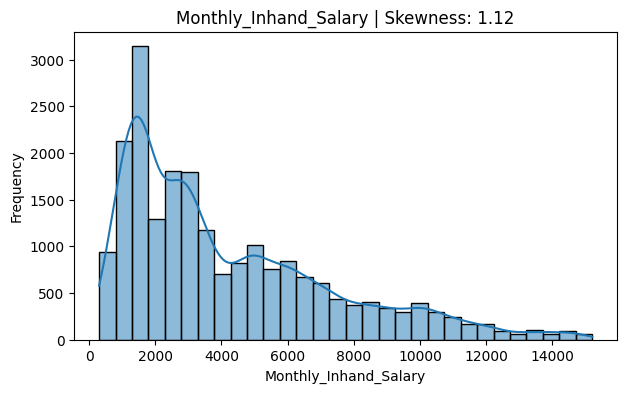

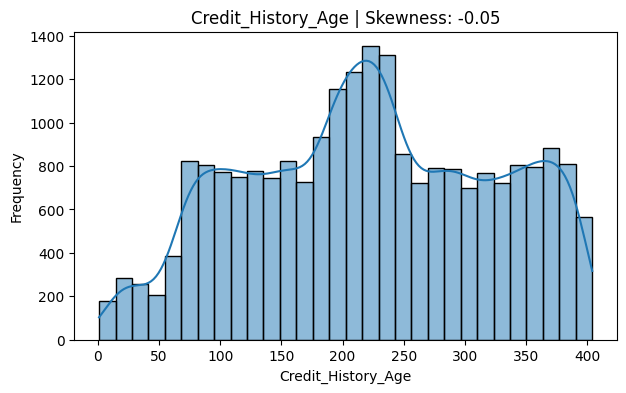

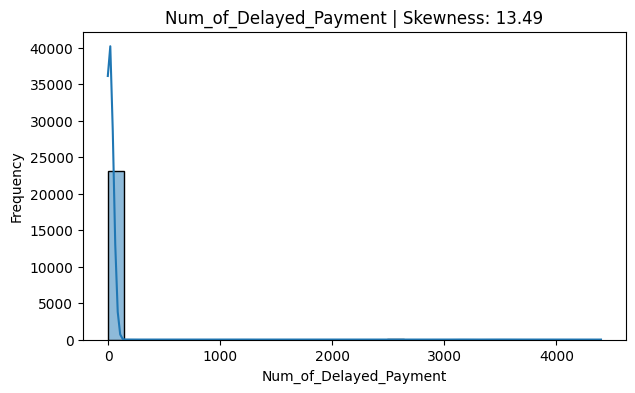

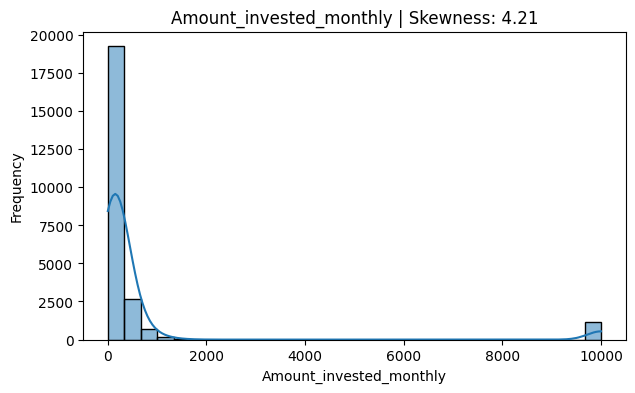

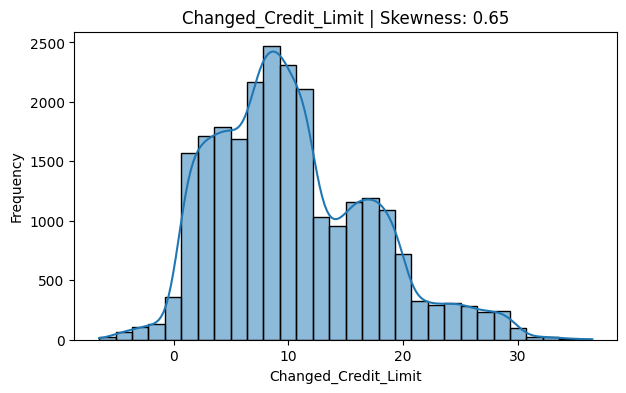

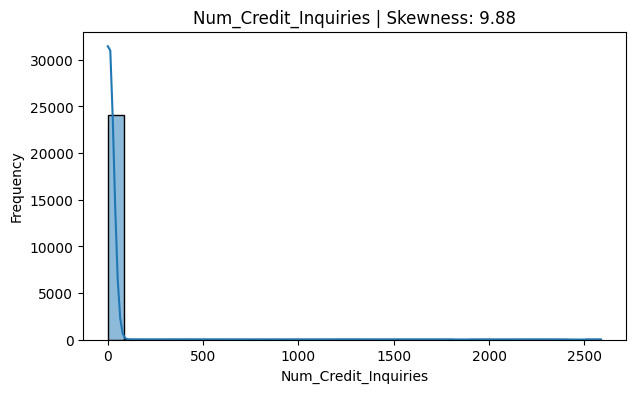

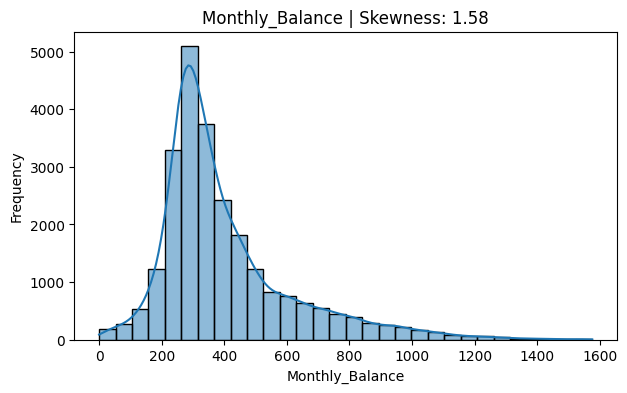

In [ ]:
missing_numeric_cols = numeric_missing_df.index.tolist()

for col in missing_numeric_cols:
    skew_val = df[col].skew()

    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col} | Skewness: {skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
missing_numeric_cols = numeric_missing_df.index.tolist()

skewness_df = pd.DataFrame({
    'Column': missing_numeric_cols,
    'Skewness': [df[col].skew() for col in missing_numeric_cols]
})

skewness_df

,Column,Skewness
0,Monthly_Inhand_Salary,1.115845
1,Credit_History_Age,-0.053894
2,Num_of_Delayed_Payment,13.492936
3,Amount_invested_monthly,4.214650
4,Changed_Credit_Limit,0.653190
5,Num_Credit_Inquiries,9.875560
6,Monthly_Balance,1.578830


In [ ]:
# median imputation
median_cols = [
    'Monthly_Inhand_Salary',
    'Num_of_Delayed_Payment',
    'Amount_invested_monthly',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Monthly_Balance'
]

for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# mean imputation
df['Credit_History_Age'] = df['Credit_History_Age'].fillna(
    round(df['Credit_History_Age'].mean())
)

In [ ]:
numeric_missing = df.select_dtypes(include=['int64', 'float64']).isnull().sum()
numeric_missing

,0
Age,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  int64  
 1   Occupation                25000 non-null  object 
 2   Annual_Income             25000 non-null  float64
 3   Monthly_Inhand_Salary     25000 non-null  float64
 4   Num_Bank_Accounts         25000 non-null  int64  
 5   Num_Credit_Card           25000 non-null  int64  
 6   Interest_Rate             25000 non-null  int64  
 7   Num_of_Loan               25000 non-null  int64  
 8   Type_of_Loan              25000 non-null  object 
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    25000 non-null  float64
 11  Changed_Credit_Limit      25000 non-null  float64
 12  Num_Credit_Inquiries      25000 non-null  float64
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

## Outlier Check

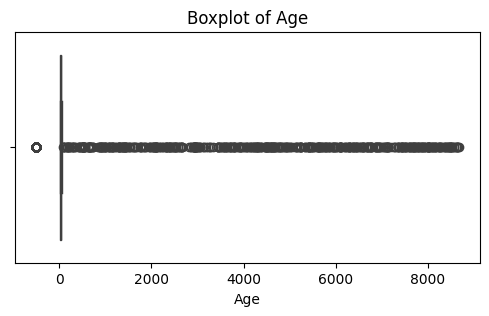

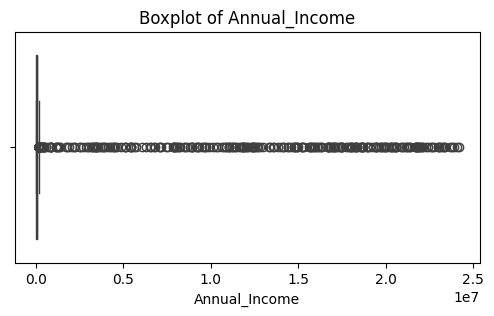

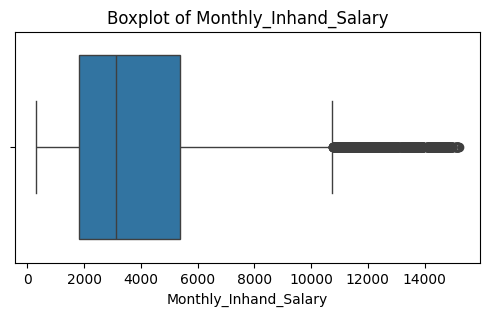

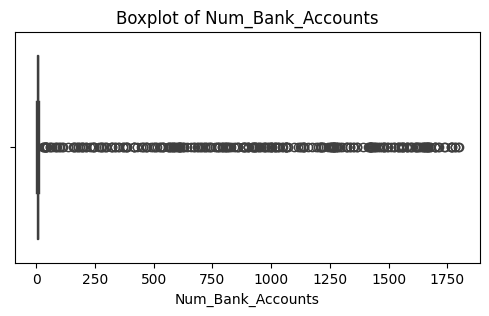

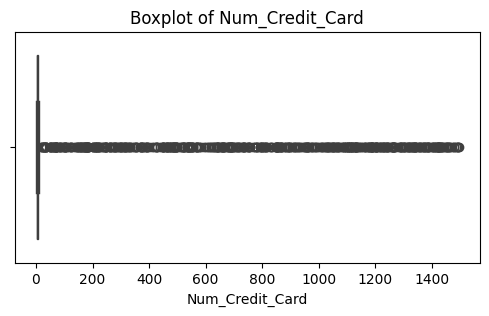

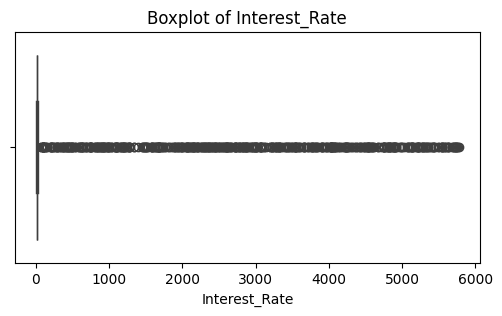

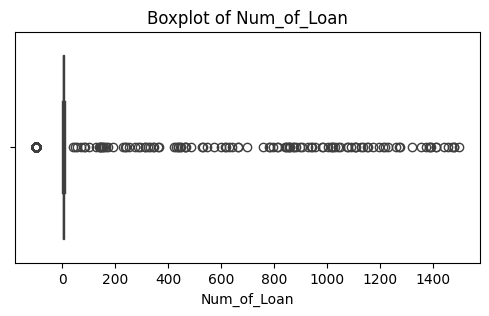

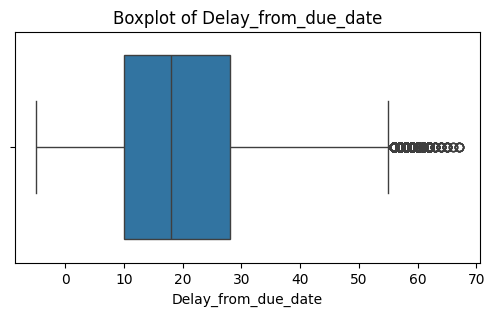

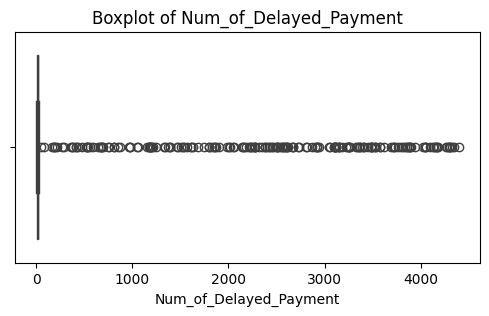

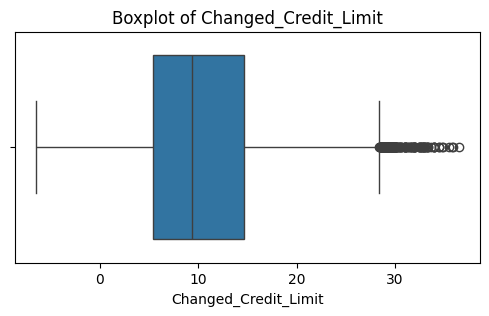

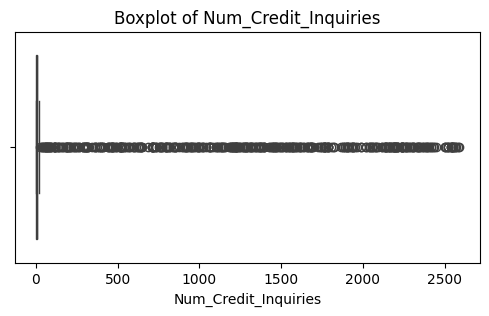

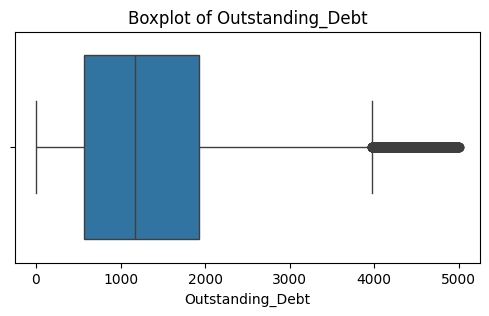

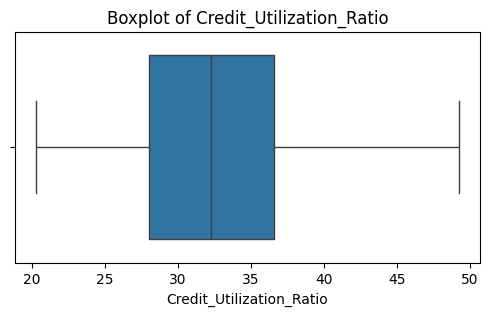

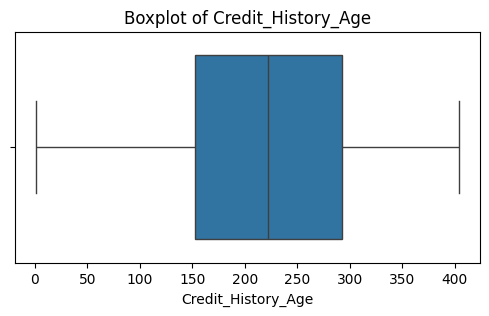

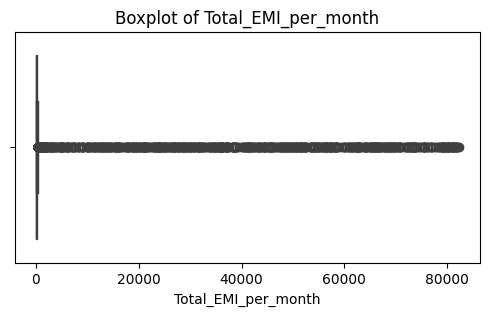

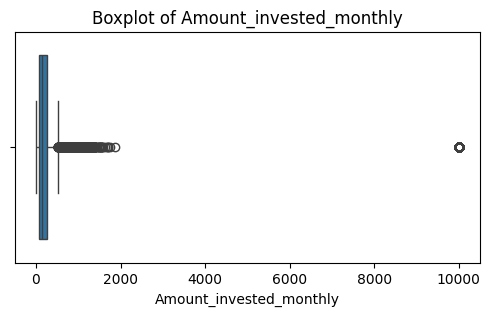

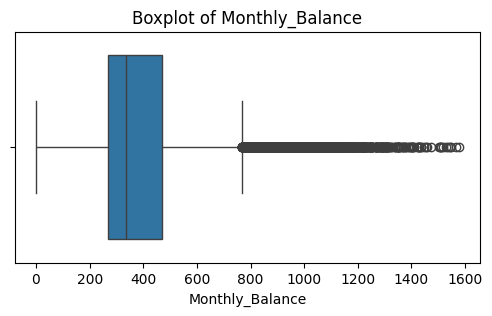

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,117.090440,7.167958e+02,-500.000000,24.000000,33.000000,42.000000,8.666000e+03
Annual_Income,25000.0,184874.755599,1.481741e+06,7006.035000,19548.868750,37824.960000,73020.540000,2.417715e+07
Monthly_Inhand_Salary,25000.0,4039.981681,2.945528e+03,303.645417,1804.031667,3118.399167,5390.500625,1.520463e+04
Num_Bank_Accounts,25000.0,16.189320,1.139799e+02,-1.000000,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,25000.0,22.204800,1.286359e+02,0.000000,4.000000,5.000000,7.000000,1.495000e+03
Interest_Rate,25000.0,72.883720,4.645336e+02,1.000000,8.000000,13.000000,20.000000,5.774000e+03
Num_of_Loan,25000.0,2.876120,6.187944e+01,-100.000000,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,25000.0,21.029360,1.481596e+01,-5.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,25000.0,31.776040,2.340165e+02,-3.000000,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,25000.0,10.343160,6.703808e+00,-6.490000,5.420000,9.370000,14.612500,3.649000e+01


Bisa dilihat secara sekilas bahwa ada keanehan disini.


Contoh yang paling terlihat adalah minimum umur di angka -500 dimana tidak mungkin terjadi di dunia nyata.

In [ ]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier Percentage': round((len(outliers)/len(df))*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    by='Outlier Percentage',
    ascending=False
)

outlier_df

,Column,Outlier Count,Outlier Percentage
15,Amount_invested_monthly,2747,10.99
16,Monthly_Balance,1886,7.54
14,Total_EMI_per_month,1706,6.82
11,Outstanding_Debt,1326,5.30
6,Num_of_Loan,1105,4.42
2,Monthly_Inhand_Salary,1033,4.13
7,Delay_from_due_date,1001,4.00
0,Age,721,2.88
1,Annual_Income,688,2.75
4,Num_Credit_Card,556,2.22


Bisa dilihat dari hasil numerik dan grafik diatas kalau data-data numerik tsb menunjukkan adanya dua jenis outlier, yaitu outlier yang masih realistis dan outlier yang merupakan anomali data (gamasuk akal secara logika)

Nilai ekstrem pada kolom-kolom seperti pendapatan, utang, EMI, investasi, dan saldo bulanan masih mungkin terjadi dalam kondisi nyata sehingga tetap dipertahankan.

Tapi ada nilai yang secara logika tidak memungkinkan, seperti usia negatif/ribuan tahun, jumlah rekening/kartu kredit/pinjaman dalam jumlah tidak wajar, suku bunga yang terlalu besar, keterlambatan negatif, serta inquiry yang ekstrem, dianggap sebagai data tidak valid. Nilai tersebut dikonversi menjadi missing value dan ditangani melalui imputasi median.

In [ ]:
rules = {
    'Age': (18, 100),
    'Num_Bank_Accounts': (0, 20),
    'Num_Credit_Card': (0, 20),
    'Interest_Rate': (0, 50),
    'Num_of_Loan': (0, 20),
    'Num_of_Delayed_Payment': (0, 100),
    'Num_Credit_Inquiries': (0, 50)
}

for col, (low, high) in rules.items():
    df.loc[(df[col] < low) | (df[col] > high), col] = np.nan

# only negative invalid
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan

In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,22894.0,34.464925,1.012552e+01,18.000000,26.000000,34.000000,42.000000,9.900000e+01
Annual_Income,25000.0,184874.755599,1.481741e+06,7006.035000,19548.868750,37824.960000,73020.540000,2.417715e+07
Monthly_Inhand_Salary,25000.0,4039.981681,2.945528e+03,303.645417,1804.031667,3118.399167,5390.500625,1.520463e+04
Num_Bank_Accounts,24702.0,5.372318,2.594529e+00,0.000000,3.000000,5.000000,7.000000,1.100000e+01
Num_Credit_Card,24446.0,5.531334,2.073230e+00,0.000000,4.000000,5.000000,7.000000,2.000000e+01
Interest_Rate,24476.0,14.511481,8.676145e+00,1.000000,7.000000,13.000000,20.000000,3.400000e+01
Num_of_Loan,23895.0,3.528353,2.445253e+00,0.000000,2.000000,3.000000,5.000000,9.000000e+00
Delay_from_due_date,24846.0,21.173469,1.474763e+01,0.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,24648.0,13.470951,6.023093e+00,0.000000,9.000000,14.000000,18.000000,8.400000e+01
Changed_Credit_Limit,25000.0,10.343160,6.703808e+00,-6.490000,5.420000,9.370000,14.612500,3.649000e+01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22894 non-null  float64
 1   Occupation                25000 non-null  object 
 2   Annual_Income             25000 non-null  float64
 3   Monthly_Inhand_Salary     25000 non-null  float64
 4   Num_Bank_Accounts         24702 non-null  float64
 5   Num_Credit_Card           24446 non-null  float64
 6   Interest_Rate             24476 non-null  float64
 7   Num_of_Loan               23895 non-null  float64
 8   Type_of_Loan              25000 non-null  object 
 9   Delay_from_due_date       24846 non-null  float64
 10  Num_of_Delayed_Payment    24648 non-null  float64
 11  Changed_Credit_Limit      25000 non-null  float64
 12  Num_Credit_Inquiries      24584 non-null  float64
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

Karena ada yang terdapat missing value setelah melakukan outlier handling, saya akan mengimpute semuanya menggunakan median karena median adalah nilai yang normal dan tidak mudah terpengaruh seperti mean.

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

## Skewness Check

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

skew_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Skewness': df[numeric_cols].skew()
}).sort_values(by='Skewness', key=abs, ascending=False)

skew_df

,Feature,Skewness
Annual_Income,Annual_Income,12.103867
Total_EMI_per_month,Total_EMI_per_month,7.411578
Amount_invested_monthly,Amount_invested_monthly,4.321635
Monthly_Balance,Monthly_Balance,1.596632
Monthly_Inhand_Salary,Monthly_Inhand_Salary,1.337806
Outstanding_Debt,Outstanding_Debt,1.209553
Delay_from_due_date,Delay_from_due_date,0.980761
Changed_Credit_Limit,Changed_Credit_Limit,0.669199
Interest_Rate,Interest_Rate,0.513249
Num_of_Loan,Num_of_Loan,0.493697


beberapa fitur ada yang skewness parah maka harus dihandle menggunakan winsorize yang artinya data yang parah akan difilter menjadi batas maksimum/minimum

In [ ]:
skewed_cols = [
    'Annual_Income',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [ ]:
skew_df_after = pd.DataFrame({
    'Feature': numeric_cols,
    'Skewness': df[numeric_cols].skew()
}).sort_values(
    by='Skewness',
    key=abs,
    ascending=False
)

skew_df_after

,Feature,Skewness
Annual_Income,Annual_Income,1.878857
Amount_invested_monthly,Amount_invested_monthly,1.374609
Outstanding_Debt,Outstanding_Debt,-1.331608
Monthly_Balance,Monthly_Balance,-1.219965
Delay_from_due_date,Delay_from_due_date,0.980761
Changed_Credit_Limit,Changed_Credit_Limit,0.669199
Interest_Rate,Interest_Rate,0.513249
Num_of_Loan,Num_of_Loan,0.493697
Num_Credit_Inquiries,Num_Credit_Inquiries,0.487046
Num_Credit_Card,Num_Credit_Card,0.262951


## Duplicate Check

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak ada duplikat yang tercatat maka lanjut ke proses berikutnya.

## Cardinality Check

In [ ]:
cardinality_df = pd.DataFrame({
    'Column': df.select_dtypes(include='object').columns,
    'Unique Values': [df[col].nunique() for col in df.select_dtypes(include='object').columns]
}).sort_values(by='Unique Values', ascending=False)

cardinality_df

,Column,Unique Values
1,Type_of_Loan,5748
0,Occupation,16
4,Payment_Behaviour,6
2,Credit_Mix,3
5,Credit_Score,3
3,Payment_of_Min_Amount,2


In [ ]:
df['Type_of_Loan'].unique()

array(['Auto Loan, Payday Loan, Mortgage Loan, Payday Loan, and Student Loan',
       'Auto Loan, Debt Consolidation Loan, Debt Consolidation Loan, Not Specified, Credit-Builder Loan, Auto Loan, Personal Loan, Payday Loan, and Home Equity Loan',
       'Mortgage Loan, Mortgage Loan, Home Equity Loan, Payday Loan, Debt Consolidation Loan, and Not Specified',
       ...,
       'Auto Loan, Debt Consolidation Loan, Credit-Builder Loan, Auto Loan, and Payday Loan',
       'Not Specified, Credit-Builder Loan, Credit-Builder Loan, Credit-Builder Loan, and Credit-Builder Loan',
       'Debt Consolidation Loan, Auto Loan, Not Specified, and Not Specified'],
      dtype=object)

In [ ]:
df = df.drop(columns=['Type_of_Loan'])

Setelah saya cek, fitur Num_of_Loan adalah feature engineering dari Type_of_Loan sehingga saya memutuskan untuk mengahapus yang cardinalitynya tidak masuk akal (Type of Loan). Type of Loan juga memiliki cardinality yang sangat tinggi, itu adalah alasan kedua kenapa saya memutuskan untuk langsung drop kolom tersebut.

## Feature Engineering

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  float64
 1   Occupation                25000 non-null  object 
 2   Annual_Income             25000 non-null  float64
 3   Monthly_Inhand_Salary     25000 non-null  float64
 4   Num_Bank_Accounts         25000 non-null  float64
 5   Num_Credit_Card           25000 non-null  float64
 6   Interest_Rate             25000 non-null  float64
 7   Num_of_Loan               25000 non-null  float64
 8   Delay_from_due_date       25000 non-null  float64
 9   Num_of_Delayed_Payment    25000 non-null  float64
 10  Changed_Credit_Limit      25000 non-null  float64
 11  Num_Credit_Inquiries      25000 non-null  float64
 12  Credit_Mix                25000 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

Selain itu saya menambahkan fitur Debt_to_Income_Ratio, yaitu perbandingan antara total utang dan pendapatan tahunan nasabah. Fitur ini dipilih karena beban utang akan lebih bermakna jika dilihat relatif terhadap kemampuan finansial nasabah, bukan hanya dari nilai utang

### Debt_to_Income_Ratio

In [ ]:
df['Debt_to_Income_Ratio'] = np.where(
    df['Annual_Income'] > 0,
    df['Outstanding_Debt'] / df['Annual_Income'],
    0
)

In [ ]:
df[['Outstanding_Debt', 'Annual_Income', 'Debt_to_Income_Ratio']].head()

,Outstanding_Debt,Annual_Income,Debt_to_Income_Ratio
0,8.432567,9.615558,0.876971
1,7.972980,11.223960,0.710354
2,7.860872,9.931867,0.791480
3,6.356663,11.618106,0.547134
4,6.214228,9.863497,0.630023


### Risk Score

Saya menggabungkan beberapa indikator yang buruk untuk mendapatkan model yang lebih baik

In [ ]:
df['Risk_Score'] = (
    0.5 * df['Delay_from_due_date']
    + 0.3 * df['Num_of_Delayed_Payment']
    + 0.2 * df['Num_Credit_Inquiries']
)

In [ ]:
df['Risk_Score'].head()

,Risk_Score
0,28.1
1,15.2
2,18.8
3,10.1
4,8.0


In [ ]:
df['Risk_Score'].head()

,Risk_Score
0,28.1
1,15.2
2,18.8
3,10.1
4,8.0


In [ ]:
def classify_risk(row):
    if (
        row['Delay_from_due_date'] > 30 or
        row['Num_of_Delayed_Payment'] > 10 or
        row['Num_Credit_Inquiries'] > 8
    ):
        return 'High'

    elif (
        row['Delay_from_due_date'] > 10 or
        row['Num_of_Delayed_Payment'] > 4 or
        row['Num_Credit_Inquiries'] > 4
    ):
        return 'Medium'

    else:
        return 'Low'

df['Risk_Level'] = df.apply(classify_risk, axis=1)

df['Risk_Level'].value_counts()

,count
Risk_Level,
High,17861
Medium,6008
Low,1131


Risk_level = high orang ini memiliki perilaku kredit yang risky. Karena itu akan saya langsung encode saja 0 = low, 1 = medium, 2 = high

In [ ]:
df['Risk_Level'].head()

,Risk_Level
0,High
1,High
2,High
3,Medium
4,Medium


In [ ]:
risk_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

df['Risk_Level'] = df['Risk_Level'].map(risk_mapping)

In [ ]:
df['Risk_Level'].head()

,Risk_Level
0,2
1,2
2,2
3,1
4,1


## EMI burden

Mengukur seberapa besar cicilan dibandingkan dengan income. Contohnya 40% income akan dipakai untuk byar cicilan.

In [ ]:
df['EMI_Burden'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1)
df['EMI_Burden'].head()

,EMI_Burden
0,0.455439
1,0.644866
2,0.528851
3,0.494869
4,0.000000


## Financial Exposure

Financial Exposure dibuat untuk menggambarkan seberapa besar keterlibatan seseorang dalam aktivitas keuangan, berdasarkan jumlah rekening bank, kartu kredit, dan pinjaman yang dimiliki. Semakin tinggi nilainya, semakin kompleks kewajiban finansial yang harus dikelola, sehingga potensi risikonya juga bisa meningkat.

In [ ]:
df['Financial_Exposure'] = (
    df['Num_Bank_Accounts']
    + df['Num_Credit_Card']
    + df['Num_of_Loan']
)

In [ ]:
df['Financial_Exposure'].head()

,Financial_Exposure
0,17.0
1,25.0
2,22.0
3,8.0
4,4.0


# Correlation Checks

## Numerical

In [ ]:
df['Credit_Score_Encoded'] = df['Credit_Score'].map({
    'Poor': 0,
    'Standard': 1,
    'Good': 2
})

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Credit_Score_Encoded')

pearson_target = []

for col in numeric_cols:
    corr = df[col].corr(df['Credit_Score_Encoded'], method='pearson')

    pearson_target.append({
        'Feature': col,
        'Pearson Correlation': round(corr, 2),
        'Strength': (
            'Very Strong' if abs(corr) >= 0.8 else
            'Strong' if abs(corr) >= 0.6 else
            'Moderate' if abs(corr) >= 0.4 else
            'Weak' if abs(corr) >= 0.2 else
            'Very Weak'
        )
    })

pearson_target_df = pd.DataFrame(pearson_target).sort_values(
    by='Pearson Correlation',
    ascending=False
)

pearson_target_df

,Feature,Pearson Correlation,Strength
13,Credit_History_Age,0.38,Weak
2,Monthly_Inhand_Salary,0.19,Very Weak
16,Monthly_Balance,0.18,Very Weak
1,Annual_Income,0.17,Very Weak
0,Age,0.12,Very Weak
15,Amount_invested_monthly,0.10,Very Weak
12,Credit_Utilization_Ratio,0.04,Very Weak
14,Total_EMI_per_month,-0.09,Very Weak
20,EMI_Burden,-0.12,Very Weak
9,Changed_Credit_Limit,-0.16,Very Weak


## Categorical

In [ ]:
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include='object').columns.drop('Credit_Score')

chi_results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['Credit_Score'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi_results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 2),
        'P-Value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values(
    by='P-Value'
)

chi_df

,Feature,Chi2 Statistic,P-Value,Significant
1,Credit_Mix,7710.33,0.000000e+00,Yes
2,Payment_of_Min_Amount,4523.77,0.000000e+00,Yes
3,Payment_Behaviour,367.60,7.311558e-73,Yes
0,Occupation,69.06,6.482753e-05,Yes


Feature selection dilakukan berdasarkan hasil Pearson correlation terhadap target variable. Fitur dengan korelasi yang sangat rendah (mendekati nol) berpotensi menambah noise pada model.

Annual Income sebenarnya masih berhubungan dalam konteks credit score, tapi di sisi lain saya sudah menggunakan feature engineering yang sudah menhitung annual income dibagi dengan hutang yang dimiliki yang dinamakan kolom income to debt ratio yang malah lebih berguna untuk membuat model jadi saya akan melakukan drop.


In [ ]:
drop_cols_1 = [
    'Age',
    'Amount_invested_monthly',
    'Credit_Utilization_Ratio',
    'Monthly_Balance',
    'Monthly_Inhand_Salary',
    'Total_EMI_per_month',
    'EMI_Burden',
    'Risk_Level',
    'Annual_Income'
]

df = df.drop(columns=drop_cols_1)

In [ ]:
df.columns

Index(['Occupation', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
       'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score', 'Debt_to_Income_Ratio',
       'Risk_Score', 'Financial_Exposure', 'Credit_Score_Encoded'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Occupation              25000 non-null  object 
 1   Num_Bank_Accounts       25000 non-null  float64
 2   Num_Credit_Card         25000 non-null  float64
 3   Interest_Rate           25000 non-null  float64
 4   Num_of_Loan             25000 non-null  float64
 5   Delay_from_due_date     25000 non-null  float64
 6   Num_of_Delayed_Payment  25000 non-null  float64
 7   Changed_Credit_Limit    25000 non-null  float64
 8   Num_Credit_Inquiries    25000 non-null  float64
 9   Credit_Mix              25000 non-null  object 
 10  Outstanding_Debt        25000 non-null  float64
 11  Credit_History_Age      25000 non-null  float64
 12  Payment_of_Min_Amount   25000 non-null  object 
 13  Payment_Behaviour       25000 non-null  object 
 14  Credit_Score            25000 non-null

# Target Distribution Check

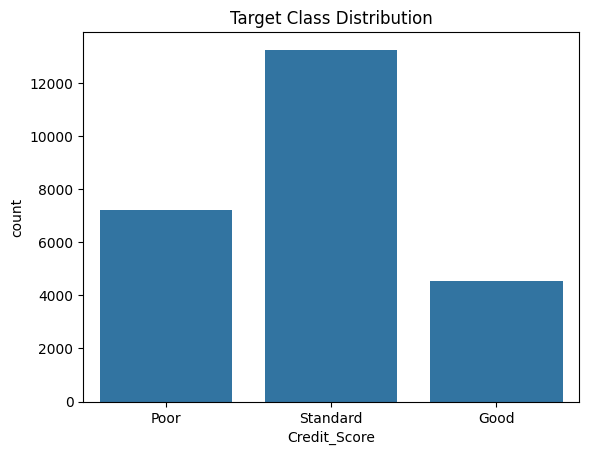

In [ ]:
sns.countplot(x='Credit_Score', data=df)
plt.title('Target Class Distribution')
plt.show()

Bisa dilihat meskipun imbalance tapi belum masuk ke extreme imbalance sehingga saya akan mecoba training baseline terlebih dahulu belum memakai imbalance handling.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Occupation              25000 non-null  object 
 1   Num_Bank_Accounts       25000 non-null  float64
 2   Num_Credit_Card         25000 non-null  float64
 3   Interest_Rate           25000 non-null  float64
 4   Num_of_Loan             25000 non-null  float64
 5   Delay_from_due_date     25000 non-null  float64
 6   Num_of_Delayed_Payment  25000 non-null  float64
 7   Changed_Credit_Limit    25000 non-null  float64
 8   Num_Credit_Inquiries    25000 non-null  float64
 9   Credit_Mix              25000 non-null  object 
 10  Outstanding_Debt        25000 non-null  float64
 11  Credit_History_Age      25000 non-null  float64
 12  Payment_of_Min_Amount   25000 non-null  object 
 13  Payment_Behaviour       25000 non-null  object 
 14  Credit_Score            25000 non-null

In [ ]:
df = df.drop(columns=['Credit_Score_Encoded']) # biar ga leak, nanti buat mapping yang baru aja

# Encoding Target

In [ ]:
df['Credit_Score'] = df['Credit_Score'].map({
    'Poor': 0,
    'Standard': 1,
    'Good': 2
})

# Splitting

In [ ]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Occupation              25000 non-null  object 
 1   Num_Bank_Accounts       25000 non-null  float64
 2   Num_Credit_Card         25000 non-null  float64
 3   Interest_Rate           25000 non-null  float64
 4   Num_of_Loan             25000 non-null  float64
 5   Delay_from_due_date     25000 non-null  float64
 6   Num_of_Delayed_Payment  25000 non-null  float64
 7   Changed_Credit_Limit    25000 non-null  float64
 8   Num_Credit_Inquiries    25000 non-null  float64
 9   Credit_Mix              25000 non-null  object 
 10  Outstanding_Debt        25000 non-null  float64
 11  Credit_History_Age      25000 non-null  float64
 12  Payment_of_Min_Amount   25000 non-null  object 
 13  Payment_Behaviour       25000 non-null  object 
 14  Debt_to_Income_Ratio    25000 non-null

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 25000 entries, 0 to 24999
Series name: Credit_Score
Non-Null Count  Dtype
--------------  -----
25000 non-null  int64
dtypes: int64(1)
memory usage: 195.4 KB


# Fitur Encode

Menggunakan OHE karena tidak ada yang ordinal

In [ ]:
cat_cols = X_train.select_dtypes(include='object').columns
cat_cols

Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

In [ ]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

X_train_final = pd.concat([X_train_num, X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_df], axis=1)

In [ ]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 21283 to 13888
Data columns (total 36 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Num_Bank_Accounts                                   20000 non-null  float64
 1   Num_Credit_Card                                     20000 non-null  float64
 2   Interest_Rate                                       20000 non-null  float64
 3   Num_of_Loan                                         20000 non-null  float64
 4   Delay_from_due_date                                 20000 non-null  float64
 5   Num_of_Delayed_Payment                              20000 non-null  float64
 6   Changed_Credit_Limit                                20000 non-null  float64
 7   Num_Credit_Inquiries                                20000 non-null  float64
 8   Outstanding_Debt                                    20000 non-null  float64
 

In [ ]:
X_test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 9373 to 20470
Data columns (total 36 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Num_Bank_Accounts                                   5000 non-null   float64
 1   Num_Credit_Card                                     5000 non-null   float64
 2   Interest_Rate                                       5000 non-null   float64
 3   Num_of_Loan                                         5000 non-null   float64
 4   Delay_from_due_date                                 5000 non-null   float64
 5   Num_of_Delayed_Payment                              5000 non-null   float64
 6   Changed_Credit_Limit                                5000 non-null   float64
 7   Num_Credit_Inquiries                                5000 non-null   float64
 8   Outstanding_Debt                                    5000 non-null   float64
 9 

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Modelling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Baseline

### Logistic Regression

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.654

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.56      0.61      1440
           1       0.67      0.75      0.71      2651
           2       0.56      0.52      0.54       909

    accuracy                           0.65      5000
   macro avg       0.64      0.61      0.62      5000
weighted avg       0.65      0.65      0.65      5000



Model Logistic Regression memperoleh accuracy sebesar 65,4%, yang menunjukkan bahwa sekitar 65% data berhasil diklasifikasikan dengan benar. Performa terbaik terdapat pada kelas Standard (F1-score 0,71), sedangkan kelas Good memiliki performa terendah (F1-score 0,54). Hal ini menunjukkan bahwa model lebih mudah mengenali kelas mayoritas dibandingkan kelas minoritas.


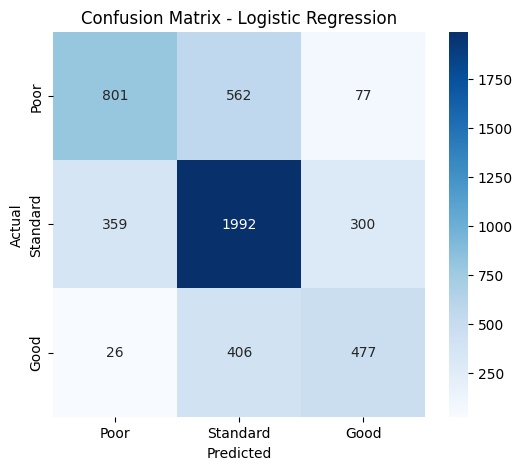

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Poor', 'Standard', 'Good'],
    yticklabels=['Poor', 'Standard', 'Good']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar, terutama pada kelas Standard. Namun, masih banyak data pada kelas Poor dan Good yang diprediksi sebagai Standard, sehingga model masih mengalami kesulitan dalam membedakan ketiga kelas secara konsisten.


### ROC

In [ ]:
y_prob_lr = lr.predict_proba(X_test_scaled)

In [ ]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

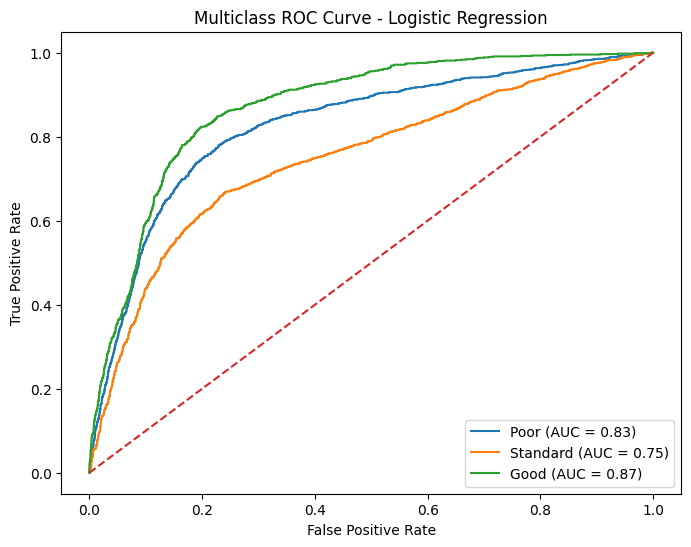

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = {}
tpr = {}
roc_auc = {}

class_names = ['Poor', 'Standard', 'Good']

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Logistic Regression')
plt.legend()
plt.show()

Nilai AUC untuk kelas Poor, Standard, dan Good masing-masing adalah 0,83, 0,75, dan 0,87. Seluruh nilai AUC berada di atas 0,70, sehingga menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan setiap kelas, meskipun performa klasifikasinya masih dapat ditingkatkan.

**Kesimpulan**

Secara keseluruhan, Logistic Regression sebagai model baseline memberikan performa yang cukup baik dengan accuracy 65,4%. Model paling baik dalam mengenali kelas Standard, sedangkan prediksi pada kelas Good masih perlu ditingkatkan. Hasil ini dapat dijadikan acuan sebelum dilakukan proses optimasi atau penanganan class imbalance pada tahap selanjutnya.

### Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_final, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_final)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.751

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75      1440
           1       0.77      0.79      0.78      2651
           2       0.68      0.66      0.67       909

    accuracy                           0.75      5000
   macro avg       0.74      0.73      0.73      5000
weighted avg       0.75      0.75      0.75      5000



Model Random Forest memperoleh accuracy sebesar 75,1%, yang berarti sekitar 75% data berhasil diklasifikasikan dengan benar. Dibandingkan dengan Logistic Regression (65,4%), Random Forest menunjukkan peningkatan performa yang cukup signifikan. Kelas Standard memiliki performa terbaik dengan F1-score 0,78, diikuti oleh kelas Poor (0,75), sedangkan kelas Good masih memiliki nilai F1-score paling rendah (0,67). Secara keseluruhan, nilai weighted F1-score sebesar 0,75 menunjukkan bahwa model mampu memberikan hasil klasifikasi yang lebih baik dan lebih seimbang pada ketiga kelas.



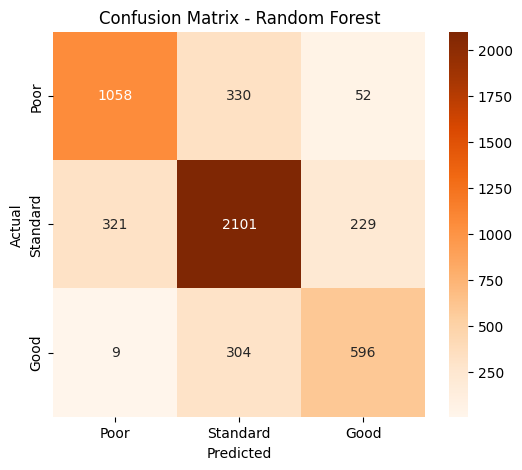

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Poor', 'Standard', 'Good'],
    yticklabels=['Poor', 'Standard', 'Good']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Berdasarkan confusion matrix, Random Forest berhasil mengklasifikasikan 1.058 data Poor, 2.101 data Standard, dan 596 data Good dengan benar. Meskipun masih terdapat beberapa kesalahan prediksi, jumlahnya lebih sedikit dibandingkan model Logistic Regression. Hal ini menunjukkan bahwa Random Forest mampu membedakan ketiga kelas dengan lebih baik, terutama dalam mengurangi kesalahan klasifikasi pada kelas Poor dan Good.


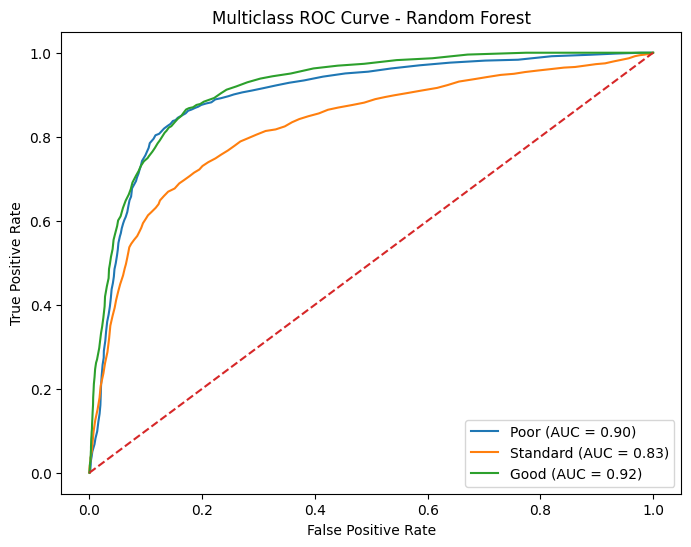

In [ ]:
y_prob_rf = rf.predict_proba(X_test_final)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

class_names = ['Poor', 'Standard', 'Good']

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.title('Multiclass ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Kurva ROC menunjukkan bahwa Random Forest memiliki kemampuan diskriminasi yang sangat baik dengan nilai AUC sebesar 0,90 untuk kelas Poor, 0,83 untuk kelas Standard, dan 0,92 untuk kelas Good. Seluruh nilai AUC mengalami peningkatan dibandingkan Logistic Regression, yang menunjukkan bahwa Random Forest lebih mampu membedakan setiap kelas berdasarkan probabilitas prediksinya.

**Kesimpulan**

Secara keseluruhan, Random Forest memberikan performa yang lebih baik dibandingkan Logistic Regression. Hal ini terlihat dari peningkatan accuracy dari 65,4% menjadi 75,1%, peningkatan weighted F1-score dari 0,65 menjadi 0,75, serta nilai AUC yang juga lebih tinggi pada seluruh kelas. Dengan hasil tersebut, Random Forest mampu mengklasifikasikan data credit score dengan lebih akurat dan lebih seimbang sehingga menjadi model yang lebih baik dibandingkan model baseline Logistic Regression.

### XGBoost

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test_final)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.737

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73      1440
           1       0.75      0.79      0.77      2651
           2       0.67      0.64      0.65       909

    accuracy                           0.74      5000
   macro avg       0.72      0.71      0.72      5000
weighted avg       0.74      0.74      0.74      5000



Model XGBoost memperoleh accuracy sebesar 73,7%, yang berarti sekitar 74% data berhasil diklasifikasikan dengan benar. Performa terbaik terdapat pada kelas Standard dengan F1-score 0,77, sedangkan kelas Poor dan Good masing-masing memperoleh F1-score 0,73 dan 0,65. Nilai weighted F1-score sebesar 0,74 menunjukkan bahwa model memiliki performa yang cukup baik dalam mengklasifikasikan ketiga kelas, meskipun sedikit lebih rendah dibandingkan Random Forest.


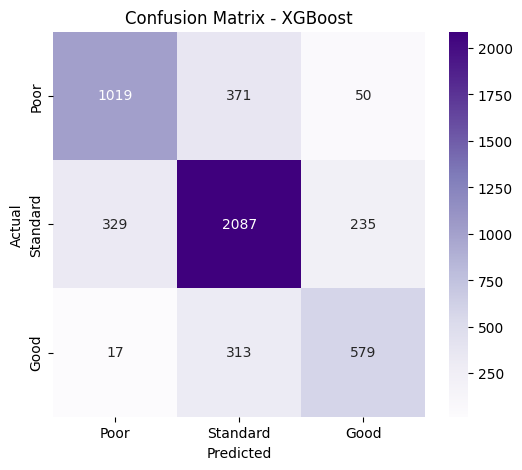

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Poor', 'Standard', 'Good'],
    yticklabels=['Poor', 'Standard', 'Good']
)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Berdasarkan confusion matrix, XGBoost berhasil mengklasifikasikan 1.019 data Poor, 2.087 data Standard, dan 579 data Good dengan benar. Sebagian besar kesalahan prediksi masih terjadi ketika data Poor dan Good diprediksi sebagai Standard, sehingga kelas Standard masih menjadi kelas yang paling mudah dikenali oleh model. Namun, secara keseluruhan jumlah prediksi yang benar sudah cukup tinggi.


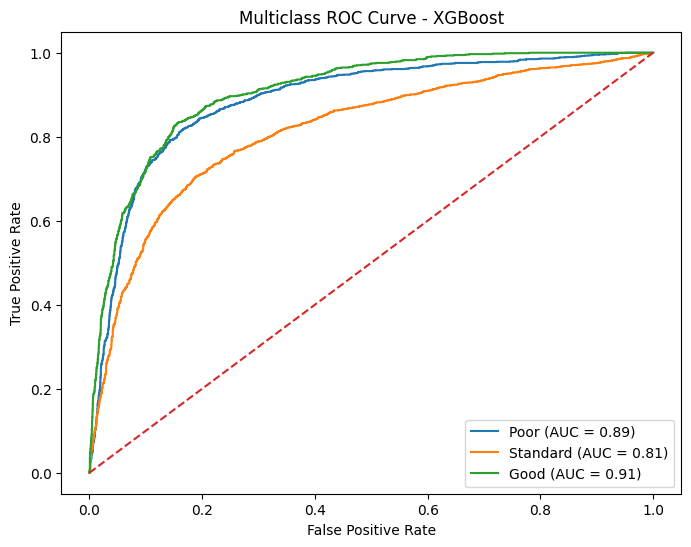

In [ ]:
y_prob_xgb = xgb.predict_proba(X_test_final)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

class_names = ['Poor', 'Standard', 'Good']

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.title('Multiclass ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Kurva ROC menunjukkan bahwa model memiliki kemampuan diskriminasi yang baik dengan nilai AUC sebesar 0,89 untuk kelas Poor, 0,81 untuk kelas Standard, dan 0,91 untuk kelas Good. Seluruh nilai AUC berada di atas 0,80, sehingga menunjukkan bahwa XGBoost mampu membedakan ketiga kelas dengan baik berdasarkan probabilitas prediksinya.


### Baseline Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='macro')
lr_recall = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='macro')
rf_recall = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

In [ ]:
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-score: {rf_f1:.4f}")

Random Forest Accuracy: 0.7510
Random Forest Precision: 0.7367
Random Forest Recall: 0.7276
Random Forest F1-score: 0.7319


In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='macro')
rf_recall = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

In [ ]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average='macro')
xgb_recall = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy],
    'Precision': [lr_precision, rf_precision, xgb_precision],
    'Recall': [lr_recall, rf_recall, xgb_recall],
    'F1-Score': [lr_f1, rf_f1, xgb_f1]
}).round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.654,0.6356,0.6108,0.6204
1,Random Forest,0.751,0.7367,0.7276,0.7319
2,XGBoost,0.737,0.7233,0.7106,0.7165


Berdasarkan perbandingan performa tiga model klasifikasi, Random Forest menunjukkan performa terbaik dengan accuracy sebesar 72.76%, precision 73.67%, recall 72.76%, dan F1-score 73.19%.

Logistic Regression menghasilkan performa terendah karena model linear kurang mampu menangkap pola hubungan yang kompleks pada data credit scoring. XGBoost menunjukkan performa yang cukup baik, namun masih sedikit di bawah Random Forest. Oleh karena itu, Random Forest dipilih sebagai model terbaik untuk prediksi credit score (sebelum hyperparameter tuning). Model ini masih bisa ditingkatkan, maka dari itu saya akan mencoba hyperparameter tuning menggunakan optuna, cv, dan imbalance handling menggunakan smote atau weightclass

# Tuned

Saya akan menocba tuning dengan menggunakan imbalance handling seperti smote dan classweight lalu saya akan compare keduanya sebelum memilih best model.

## CV + OPTUNA + WEIGHT CLASS

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score


# CROSS VALIDATION
skf_cw = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# CLASS WEIGHT
classes_cw = np.unique(y_train)

weights_cw = compute_class_weight(
    class_weight='balanced',
    classes=classes_cw,
    y=y_train
)

class_weight_dict_cw = dict(zip(classes_cw, weights_cw))

sample_weights_cw = np.array([class_weight_dict_cw[y] for y in y_train])

print("Class Weights:", class_weight_dict_cw)


# LOGISTIC REGRESSION
def objective_lr_cw(trial):
    model = LogisticRegression(
        C=trial.suggest_float("C", 0.001, 10, log=True),
        solver='lbfgs',
        max_iter=3000,
        class_weight=trial.suggest_categorical(
            "class_weight",
            [None, 'balanced']
        ),
        random_state=RANDOM_STATE
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=skf_cw,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


# RANDOM FOREST
def objective_rf_cw(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical(
            "max_features",
            ['sqrt', 'log2']
        ),
        class_weight=trial.suggest_categorical(
            "class_weight",
            [None, 'balanced']
        ),
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=skf_cw,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


# XGBOOST
def objective_xgb_cw(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    f1_scores = []
    for train_idx, val_idx in skf_cw.split(X_train_scaled, y_train):

        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        sample_weight_fold = sample_weights_cw[train_idx]


        model.fit(X_train_fold, y_train_fold, sample_weight=sample_weight_fold)


        y_pred_val = model.predict(X_val_fold)
        f1_scores.append(f1_score(y_val_fold, y_pred_val, average='macro'))

    score = np.mean(f1_scores)

    return score


# RUN OPTUNA
print("=== CLASS WEIGHT + OPTUNA START ===")

study_lr_cw = optuna.create_study(direction="maximize")
study_lr_cw.optimize(objective_lr_cw, n_trials=20)

study_rf_cw = optuna.create_study(direction="maximize")
study_rf_cw.optimize(objective_rf_cw, n_trials=20)

study_xgb_cw = optuna.create_study(direction="maximize")
study_xgb_cw.optimize(objective_xgb_cw, n_trials=20)


# BUILD BEST MODELS
best_lr_cw = LogisticRegression(
    **study_lr_cw.best_params,
    solver='lbfgs',
    max_iter=3000,
    random_state=RANDOM_STATE
)

best_rf_cw = RandomForestClassifier(
    **study_rf_cw.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb_cw = XGBClassifier(
    **study_xgb_cw.best_params,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)

# FINAL TRAINING
best_lr_cw.fit(X_train_scaled, y_train)

best_rf_cw.fit(X_train_scaled, y_train)

best_xgb_cw.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights_cw
)


# BEST RESULTS
print("\n=== BEST RESULTS (CLASS WEIGHT) ===")

print("\nLogistic Regression")
print("Best Params:", study_lr_cw.best_params)
print("Best CV F1-Macro:", study_lr_cw.best_value)

print("\nRandom Forest")
print("Best Params:", study_rf_cw.best_params)
print("Best CV F1-Macro:", study_rf_cw.best_value)

print("\nXGBoost")
print("Best Params:", study_xgb_cw.best_params)
print("Best CV F1-Macro:", study_xgb_cw.best_value)

[I 2026-06-12 06:05:02,650] A new study created in memory with name: no-name-7820b47b-7589-4733-9491-b02d2300ef16


Class Weights: {np.int64(0): np.float64(1.158010537895895), np.int64(1): np.float64(0.6285750204286882), np.int64(2): np.float64(1.8330125561360096)}
=== CLASS WEIGHT + OPTUNA START ===


[I 2026-06-12 06:05:06,732] Trial 0 finished with value: 0.6150913407168032 and parameters: {'C': 0.1596550841208978, 'class_weight': None}. Best is trial 0 with value: 0.6150913407168032.
[I 2026-06-12 06:05:08,113] Trial 1 finished with value: 0.6407365869122936 and parameters: {'C': 0.007125626328409287, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6407365869122936.
[I 2026-06-12 06:05:11,117] Trial 2 finished with value: 0.6422562928266246 and parameters: {'C': 5.392094306131101, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.6422562928266246.
[I 2026-06-12 06:05:12,534] Trial 3 finished with value: 0.6413968556617491 and parameters: {'C': 0.014973323065812526, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.6422562928266246.
[I 2026-06-12 06:05:13,926] Trial 4 finished with value: 0.6422493187067388 and parameters: {'C': 0.7038699839127726, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.6422562928266246.
[I 2026-06-12 06:05:14,881] 


=== BEST RESULTS (CLASS WEIGHT) ===

Logistic Regression
Best Params: {'C': 9.8809342154209, 'class_weight': 'balanced'}
Best CV F1-Macro: 0.6422964403954048

Random Forest
Best Params: {'n_estimators': 391, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}
Best CV F1-Macro: 0.7146315359181107

XGBoost
Best Params: {'n_estimators': 246, 'max_depth': 9, 'learning_rate': 0.1389024402355467, 'subsample': 0.8146893479482127, 'colsample_bytree': 0.6373032206020416, 'gamma': 0.04200978043364293}
Best CV F1-Macro: 0.7183204664665944


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models_cw = {
    "LogisticRegression_CW": best_lr_cw,
    "RandomForest_CW": best_rf_cw,
    "XGBoost_CW": best_xgb_cw
}

results_list_cw = []

classes_cw = np.unique(y_test)

for name, model in models_cw.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr',
        average='macro',
        labels=classes_cw
    )

    results_list_cw.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df_cw = pd.DataFrame(results_list_cw).round(4)

results_df_cw

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LogisticRegression_CW,0.6594,0.6435,0.6957,0.6536,0.8132
1,RandomForest_CW,0.7510,0.7352,0.7299,0.7324,0.8812
2,XGBoost_CW,0.7464,0.7261,0.7431,0.7337,0.8792


Setelah dilakukan hyperparameter tuning menggunakan Optuna, Cross Validation, dan Class Weight, seluruh model mengalami peningkatan performa dibandingkan model baseline. Logistic Regression memperoleh accuracy sebesar 65,94%, Random Forest 75,10%, dan XGBoost 74,64%. Meskipun Random Forest memiliki accuracy dan ROC-AUC sedikit lebih tinggi, XGBoost menghasilkan F1-score tertinggi sebesar 0,7337, yang menunjukkan keseimbangan terbaik antara precision dan recall. Oleh karena itu, pada penelitian ini XGBoost dipilih sebagai model terbaik karena mampu memberikan performa klasifikasi yang lebih seimbang pada seluruh kelas, terutama dalam menghadapi distribusi data yang tidak seimbang.


In [ ]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    classes = np.unique(y_test)

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr',
        average='macro',
        labels=classes
    )

    print(f"\n===== {model_name} =====")
    print(f"ROC-AUC (macro-average OVR): {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=[f'Actual {c}' for c in classes],
        columns=[f'Predicted {c}' for c in classes]
    )

    print("\nConfusion Matrix:")
    print(cm_df)

In [ ]:
models_cw = {
    "LogisticRegression_CW": best_lr_cw,
    "RandomForest_CW": best_rf_cw,
    "XGBoost_CW": best_xgb_cw
}

results_list_cw = []

# multiclass classes
classes_cw = np.unique(y_test)

for name, model_instance in models_cw.items():
    # Predict probabilities
    y_prob = model_instance.predict_proba(X_test_scaled)

    # ROC-AUC multiclass
    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr',
        average='macro',
        labels=classes_cw
    )

    # Store results
    results_list_cw.append({
        "Model": name,
        "ROC-AUC": roc_auc
    })

results_df_cw = pd.DataFrame(results_list_cw)
print(results_df_cw)

                   Model   ROC-AUC
0  LogisticRegression_CW  0.813243
1        RandomForest_CW  0.881221
2             XGBoost_CW  0.879218


In [ ]:
evaluate_model(
    "Logistic Regression (Class Weight + Optuna)",
    best_lr_cw,
    X_test_scaled,
    y_test
)

evaluate_model(
    "Random Forest (Class Weight + Optuna)",
    best_rf_cw,
    X_test_scaled,
    y_test
)

evaluate_model(
    "XGBoost (Class Weight + Optuna)",
    best_xgb_cw,
    X_test_scaled,
    y_test
)


===== Logistic Regression (Class Weight + Optuna) =====
ROC-AUC (macro-average OVR): 0.8132

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.70      0.66      1440
           1       0.79      0.59      0.68      2651
           2       0.51      0.80      0.62       909

    accuracy                           0.66      5000
   macro avg       0.64      0.70      0.65      5000
weighted avg       0.69      0.66      0.66      5000


Confusion Matrix:
          Predicted 0  Predicted 1  Predicted 2
Actual 0         1004          263          173
Actual 1          557         1567          527
Actual 2           29          154          726

===== Random Forest (Class Weight + Optuna) =====
ROC-AUC (macro-average OVR): 0.8812

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      1440
           1       0.77      0.79      0.78      2651
           2     

XGBoost dipilih sebagai best model selain karena model ini mampu menggeneralisir lebih banyak minoritas.

### Smote

In [ ]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

# Cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# LOGISTIC REGRESSION
def objective_lr(trial):
    model = LogisticRegression(
        C=trial.suggest_float("C", 0.001, 10, log=True),
        solver='lbfgs',
        max_iter=3000,
        random_state=RANDOM_STATE
    )

    pipe = Pipeline([
        ('smote', smote),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


# RANDOM FOREST
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical("max_features", ['sqrt', 'log2']),
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    pipe = Pipeline([
        ('smote', smote),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


# XGBOOST
def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        eval_metric='mlogloss',
        random_state=RANDOM_STATE
    )

    pipe = Pipeline([
        ('smote', smote),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score

print("=== OPTUNA TUNING START ===")

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=20)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

# BUILD BEST MODELS
best_lr = LogisticRegression(
    **study_lr.best_params,
    solver='lbfgs',
    max_iter=3000,
    random_state=RANDOM_STATE
)

best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb = XGBClassifier(
    **study_xgb.best_params,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)


# FINAL TRAINING (SMOTE MANUAL)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

best_lr.fit(X_train_smote, y_train_smote)
best_rf.fit(X_train_smote, y_train_smote)
best_xgb.fit(X_train_smote, y_train_smote)


# BEST RESULTS
print("\n=== BEST RESULTS ===")

print("\nLogistic Regression")
print("Best Params:", study_lr.best_params)
print("Best CV F1-Macro:", study_lr.best_value)

print("\nRandom Forest")
print("Best Params:", study_rf.best_params)
print("Best CV F1-Macro:", study_rf.best_value)

print("\nXGBoost")
print("Best Params:", study_xgb.best_params)
print("Best CV F1-Macro:", study_xgb.best_value)

[I 2026-06-12 06:25:30,605] A new study created in memory with name: no-name-2d6722ec-29d8-4489-9e8c-21157197c5f1


=== OPTUNA TUNING START ===


[I 2026-06-12 06:25:35,287] Trial 0 finished with value: 0.6403088311728216 and parameters: {'C': 0.0010299026272854541}. Best is trial 0 with value: 0.6403088311728216.
[I 2026-06-12 06:25:37,609] Trial 1 finished with value: 0.6394446733105035 and parameters: {'C': 0.06263157548273887}. Best is trial 0 with value: 0.6403088311728216.
[I 2026-06-12 06:25:40,755] Trial 2 finished with value: 0.6391975118583149 and parameters: {'C': 3.8863299317332616}. Best is trial 0 with value: 0.6403088311728216.
[I 2026-06-12 06:25:43,583] Trial 3 finished with value: 0.6395692080987985 and parameters: {'C': 0.04877194312363903}. Best is trial 0 with value: 0.6403088311728216.
[I 2026-06-12 06:25:45,853] Trial 4 finished with value: 0.639363696913428 and parameters: {'C': 0.11329870919595986}. Best is trial 0 with value: 0.6403088311728216.
[I 2026-06-12 06:25:47,794] Trial 5 finished with value: 0.6389782396201406 and parameters: {'C': 0.004220376853986838}. Best is trial 0 with value: 0.640308831


=== BEST RESULTS ===

Logistic Regression
Best Params: {'C': 0.001057591854479425}
Best CV F1-Macro: 0.6403636614204575

Random Forest
Best Params: {'n_estimators': 399, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best CV F1-Macro: 0.7164827046408673

XGBoost
Best Params: {'n_estimators': 297, 'max_depth': 8, 'learning_rate': 0.17335635444383218, 'subsample': 0.7411226228580152, 'colsample_bytree': 0.644156417870882, 'gamma': 0.0038703140875725184}
Best CV F1-Macro: 0.7092341896892858


In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

models = {
    "LogisticRegression": best_lr,
    "RandomForest": best_rf,
    "XGBoost": best_xgb
}

results_list = []

classes = np.unique(y_test)

for name, model_instance in models.items():
    y_prob = model_instance.predict_proba(X_test_scaled)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro', labels=classes)
    results_list.append({
        "Model": name,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results_list)
print(results_df)


                Model   ROC-AUC
0  LogisticRegression  0.811109
1        RandomForest  0.876491
2             XGBoost  0.875674


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import pandas as pd
import numpy as np

def evaluate_model(name, model, X_test, y_test):
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    unique_classes = np.unique(y_test)
    if len(unique_classes) > 2:

        from sklearn.preprocessing import label_binarize
        y_test_bin = label_binarize(y_test, classes=unique_classes)
        roc_val = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    else:
        roc_val = roc_auc_score(y_test, y_prob[:, 1])

    print(f"ROC-AUC (macro-average OVR): {roc_val:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in unique_classes]))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in unique_classes],
        columns=[f"Predicted {c}" for c in unique_classes]
    )

    print("\nConfusion Matrix:")
    print(cm_df)

evaluate_model("Logistic Regression (Tuned)", best_lr, X_test_scaled, y_test)
evaluate_model("Random Forest (Tuned)", best_rf, X_test_scaled, y_test)
evaluate_model("XGBoost (Tuned)", best_xgb, X_test_scaled, y_test)


===== Logistic Regression (Tuned) =====
ROC-AUC (macro-average OVR): 0.8111

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.66      1440
           1       0.79      0.59      0.68      2651
           2       0.51      0.81      0.62       909

    accuracy                           0.66      5000
   macro avg       0.65      0.70      0.65      5000
weighted avg       0.70      0.66      0.66      5000


Confusion Matrix:
          Predicted 0  Predicted 1  Predicted 2
Actual 0         1001          255          184
Actual 1          552         1567          532
Actual 2           21          154          734

===== Random Forest (Tuned) =====
ROC-AUC (macro-average OVR): 0.8765

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1440
           1       0.81      0.73      0.76      2651
           2       0.61      0.75      0.67      

Model XGBoost setelah penerapan SMOTE, Optuna, dan Cross Validation memperoleh accuracy sebesar 74%, yang menunjukkan bahwa sekitar 74% data berhasil diklasifikasikan dengan benar. Performa terbaik terdapat pada kelas Standard dengan F1-score sebesar 0,77, diikuti oleh kelas Poor dengan F1-score sebesar 0,74, sedangkan kelas Good memiliki F1-score sebesar 0,65. Nilai weighted F1-score sebesar 0,74 menunjukkan bahwa model memiliki performa yang cukup seimbang dalam mengklasifikasikan ketiga kelas. Penerapan SMOTE membantu meningkatkan kemampuan model dalam mengenali kelas minoritas, sehingga performa antar kelas menjadi lebih merata dibandingkan model baseline.

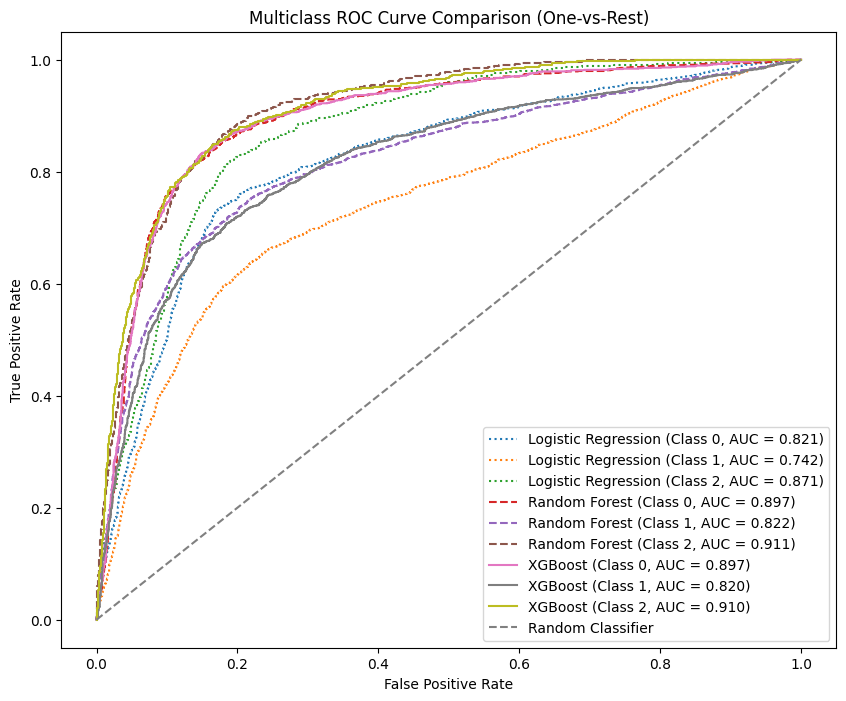

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = best_lr.classes_

y_test_bin = label_binarize(y_test, classes=classes)

y_prob_lr = best_lr.predict_proba(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Logistic Regression (Class {class_name}, AUC = {roc_auc:.3f})', linestyle=':')

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Random Forest (Class {class_name}, AUC = {roc_auc:.3f})', linestyle='--')

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'XGBoost (Class {class_name}, AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve Comparison (One-vs-Rest)')
plt.legend()
plt.show()

Berdasarkan ROC Curve multiclass, model XGBoost menunjukkan performa terbaik dengan nilai AUC masing-masing 0.900 untuk kelas Poor, 0.819 untuk kelas Standard, dan 0.910 untuk kelas Good. Nilai tersebut menunjukkan bahwa model memiliki kemampuan membedakan yang sangat baik dalam membedakan kategori credit score pelanggan. Oleh karena itu, XGBoost dipilih sebagai model paling bagus untuk Smote + CV + Optuna.

# Comparison between two imbalances handling for models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models_smote = {
    "LogisticRegression": best_lr,
    "RandomForest": best_rf,
    "XGBoost": best_xgb
}

results_list_smote = []

classes = np.unique(y_test)

for name, model in models_smote.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    results_list_smote.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-Score": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    })

results_df_smote = pd.DataFrame(results_list_smote).round(4)
results_df_smote

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LogisticRegression,0.6604,0.6451,0.6979,0.6546,0.8111
1,RandomForest,0.7414,0.7173,0.7467,0.7287,0.8765
2,XGBoost,0.7428,0.7302,0.7163,0.7227,0.8757


In [ ]:
models_cw = {
    "LogisticRegression_CW": best_lr_cw,
    "RandomForest_CW": best_rf_cw,
    "XGBoost_CW": best_xgb_cw
}

results_list_cw = []

for name, model in models_cw.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    results_list_cw.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-Score": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    })

results_df_cw_full = pd.DataFrame(results_list_cw).round(4)
results_df_cw_full

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LogisticRegression_CW,0.6594,0.6435,0.6957,0.6536,0.8132
1,RandomForest_CW,0.7510,0.7352,0.7299,0.7324,0.8812
2,XGBoost_CW,0.7464,0.7261,0.7431,0.7337,0.8792


In [ ]:
results_df_smote['Method'] = 'SMOTE + Optuna'
results_df_cw_full['Method'] = 'Class Weight + Optuna'

comparison_all = pd.concat(
    [results_df_smote, results_df_cw_full],
    ignore_index=True
)

comparison_all

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Method
0,LogisticRegression,0.6604,0.6451,0.6979,0.6546,0.8111,SMOTE + Optuna
1,RandomForest,0.7414,0.7173,0.7467,0.7287,0.8765,SMOTE + Optuna
2,XGBoost,0.7428,0.7302,0.7163,0.7227,0.8757,SMOTE + Optuna
3,LogisticRegression_CW,0.6594,0.6435,0.6957,0.6536,0.8132,Class Weight + Optuna
4,RandomForest_CW,0.7510,0.7352,0.7299,0.7324,0.8812,Class Weight + Optuna
5,XGBoost_CW,0.7464,0.7261,0.7431,0.7337,0.8792,Class Weight + Optuna


Berdasarkan distribusi data yang telah dianalisis sebelumnya, diketahui bahwa dataset memiliki ketidakseimbangan kelas, dengan kelas Standard sebagai kelas mayoritas dan kelas Good sebagai kelas minoritas. Pada kondisi seperti ini, F1-score menjadi metrik evaluasi yang lebih tepat dibandingkan accuracy karena mempertimbangkan keseimbangan antara precision dan recall. Accuracy saja dapat memberikan hasil yang tinggi apabila model lebih sering memprediksi kelas mayoritas, sehingga kurang mencerminkan kemampuan model dalam mengenali seluruh kelas.

Berdasarkan hasil evaluasi, pendekatan Class Weight + Optuna memberikan performa yang lebih baik dibandingkan SMOTE + Optuna. Pada pendekatan tersebut, XGBoost memperoleh F1-score tertinggi sebesar 0,7337, menunjukkan bahwa model memiliki keseimbangan terbaik antara precision dan recall dalam mengklasifikasikan ketiga kelas. Meskipun Random Forest memperoleh accuracy dan ROC-AUC yang sedikit lebih tinggi, selisihnya relatif kecil. Oleh karena itu, XGBoost dipilih sebagai model terbaik karena mampu memberikan performa klasifikasi yang lebih seimbang pada dataset yang memiliki ketidakseimbangan kelas